In [18]:
import pandas as pd
import numpy as np

In [19]:
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv("AQI.csv")

In [22]:
df.head()

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Assam,Nalbari,"Bata Chowk, Nalbari - PCBA",13-01-2026 00:00:00,26.446912,91.439057,SO2,7.0,8.0,8.0
1,India,Assam,Nalbari,"Bata Chowk, Nalbari - PCBA",13-01-2026 00:00:00,26.446912,91.439057,CO,20.0,22.0,21.0
2,India,Assam,Silchar,"Tarapur, Silchar - PCBA",13-01-2026 00:00:00,24.828270,92.795250,NO2,23.0,29.0,26.0
3,India,Assam,Silchar,"Tarapur, Silchar - PCBA",13-01-2026 00:00:00,24.828270,92.795250,OZONE,2.0,3.0,2.0
4,India,Assam,Sivasagar,"Girls College, Sivasagar - PCBA",13-01-2026 00:00:00,26.987634,94.636574,NO2,26.0,50.0,36.0


In [23]:
df.info

<bound method DataFrame.info of      country        state       city                             station  \
0      India        Assam    Nalbari          Bata Chowk, Nalbari - PCBA   
1      India        Assam    Nalbari          Bata Chowk, Nalbari - PCBA   
2      India        Assam    Silchar             Tarapur, Silchar - PCBA   
3      India        Assam    Silchar             Tarapur, Silchar - PCBA   
4      India        Assam  Sivasagar     Girls College, Sivasagar - PCBA   
...      ...          ...        ...                                 ...   
3341   India  West_Bengal    Kolkata   Rabindra Sarobar, Kolkata - WBPCB   
3342   India  West_Bengal    Kolkata           Victoria, Kolkata - WBPCB   
3343   India  West_Bengal    Kolkata           Victoria, Kolkata - WBPCB   
3344   India  West_Bengal   Siliguri  Ward-32 Bapupara, Siliguri - WBPCB   
3345   India  West_Bengal   Siliguri  Ward-32 Bapupara, Siliguri - WBPCB   

              last_update   latitude  longitude polluta

In [24]:
df.shape

(3346, 11)

In [25]:
df.isnull().sum()

country            0
state              0
city               0
station            0
last_update        0
latitude           0
longitude          0
pollutant_id       0
pollutant_min    227
pollutant_max    227
pollutant_avg    227
dtype: int64

<Axes: >

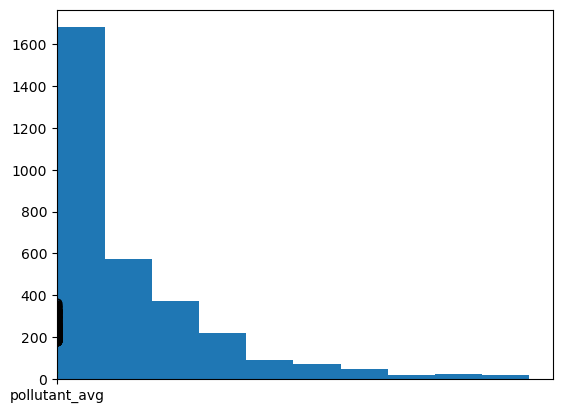

In [26]:
df["pollutant_avg"].hist()
df["pollutant_avg"].plot(kind="box")

In [27]:
df["pollutant_min"] = df["pollutant_min"].fillna(df["pollutant_min"].median())
df["pollutant_max"] = df["pollutant_max"].fillna(df["pollutant_max"].median())
df["pollutant_avg"] = df["pollutant_avg"].fillna(df["pollutant_avg"].median())

In [28]:
df.isnull().sum()

country          0
state            0
city             0
station          0
last_update      0
latitude         0
longitude        0
pollutant_id     0
pollutant_min    0
pollutant_max    0
pollutant_avg    0
dtype: int64

In [30]:
df["city"] = df["city"].str.lower().str.strip()

In [31]:
df["state"] = df["state"].str.lower().str.strip()

In [33]:
df["city"].nunique()

262

In [34]:
city_stats = df.groupby("city").agg(
    avg_pollution=("pollutant_avg", "mean"),
    peak_pollution=("pollutant_max", "max")
).reset_index()

In [39]:
city_stats.head(5)

,city,avg_pollution,peak_pollution
0,agartala,23.142857,84.0
1,agra,52.307692,500.0
2,ahmedabad,58.109091,320.0
3,ahmednagar,45.285714,129.0
4,aizawl,20.200000,59.0


In [40]:
city_stats.tail(5)

,city,avg_pollution,peak_pollution
257,virar,47.571429,144.0
258,visakhapatnam,46.428571,125.0
259,vrindavan,39.285714,319.0
260,yadgir,25.142857,92.0
261,yamuna nagar,80.142857,456.0


In [41]:
city_stats["risk_gap"] = city_stats["peak_pollution"] - city_stats["avg_pollution"]

In [45]:
#AGAR MUJHE SIRF 1 CITY KO DEKHNA HO TOH YE CODE
#----- city_stats[city_stats["city"] == "delhi"]

#LEKIN AGAR MUJHE IK YA IK SE JYADA CITY DEKHNA HO TOH
#----- city_stats[city_stats["city"].isin(["delhi", "mumbai"])]


#LEKIN ISSE RUN KRNE PAR DELHI AUR MUMBAI K VAHI COULUMNS AAJAYENGE JO city_stats MEI HAI ISILIYE AGR HUME KISI CITY K SPECIFIC COULMNS DEKHNE TOH HUM .loc USE KAR SAKTE HAI
#ISSE ROWS AUR COLUMNS SPECIFIC CHOOSE KARKE DISPLAY KAR SKTE HAI
#----- city_stats.loc[
#   city_stats["city"].isin(["delhi", "mumbai"]),
#   ["city", "avg_pollution", "peak_pollution"]
#]

In [46]:
city_stats[city_stats["city"] == "delhi"]

,city,avg_pollution,peak_pollution,risk_gap
77,delhi,109.801556,500.0,390.198444


In [47]:
city_stats[city_stats["city"].isin(["delhi", "mumbai"])]

,city,avg_pollution,peak_pollution,risk_gap
77,delhi,109.801556,500.0,390.198444
166,mumbai,47.401130,209.0,161.598870


In [48]:
city_stats.loc[
    city_stats["city"].isin(["delhi", "mumbai"]),
    ["city", "avg_pollution", "peak_pollution"]
]

,city,avg_pollution,peak_pollution
77,delhi,109.801556,500.0
166,mumbai,47.401130,209.0


In [49]:
city_stats.sort_values("peak_pollution", ascending=False).head(5)

,city,avg_pollution,peak_pollution,risk_gap
19,baddi,109.857143,500.0,390.142857
246,tonk,78.714286,500.0,421.285714
43,bhiwadi,92.928571,500.0,407.071429
96,greater noida,105.214286,500.0,394.785714
232,sri ganganagar,87.571429,500.0,412.428571


In [53]:
city_stats[["city","risk_gap"]]

,city,risk_gap
0,agartala,60.857143
1,agra,447.692308
2,ahmedabad,261.890909
3,ahmednagar,83.714286
4,aizawl,38.800000
...,...,...
257,virar,96.428571
258,visakhapatnam,78.571429
259,vrindavan,279.714286
260,yadgir,66.857143


In [55]:
#********FINAL RESULT***********
city_stats.nlargest(10, "risk_gap")

,city,avg_pollution,peak_pollution,risk_gap
240,thiruvananthapuram,35.846154,500.0,464.153846
1,agra,52.307692,500.0,447.692308
121,jodhpur,58.457143,500.0,441.542857
148,lucknow,64.609756,500.0,435.390244
173,nagaur,69.000000,500.0,431.000000
28,barbil,59.000000,482.0,423.000000
246,tonk,78.714286,500.0,421.285714
158,manesar,81.857143,500.0,418.142857
136,khurja,47.714286,464.0,416.285714
232,sri ganganagar,87.571429,500.0,412.428571


In [56]:
top10_riskcities = city_stats.nlargest(10,"risk_gap")[["city","risk_gap"]]

In [57]:
top10_riskcities

,city,risk_gap
240,thiruvananthapuram,464.153846
1,agra,447.692308
121,jodhpur,441.542857
148,lucknow,435.390244
173,nagaur,431.000000
28,barbil,423.000000
246,tonk,421.285714
158,manesar,418.142857
136,khurja,416.285714
232,sri ganganagar,412.428571


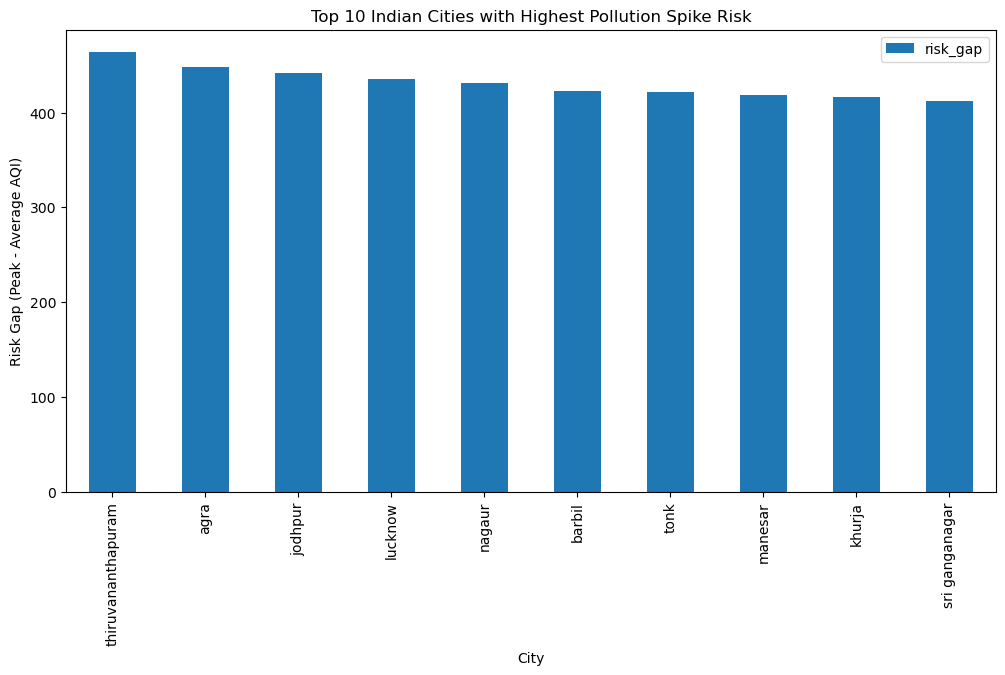

In [58]:
top10_riskcities.plot(
    x="city",
    y="risk_gap",
    kind="bar",
    figsize=(12,6),
    title="Top 10 Indian Cities with Highest Pollution Spike Risk"
)

plt.ylabel("Risk Gap (Peak - Average AQI)")
plt.xlabel("City")
plt.show()

In [59]:
top10_riskcities.to_csv("top10_pollution_risk_cities.csv", index=False)